In [1]:
import pybaseball as pyb
import pandas as pd
import matplotlib.pyplot as plt

pyb.cache.enable()

In [2]:
df = pyb.statcast(start_dt='2025-06-01', end_dt='2025-06-07')
print(df.shape)
df.head()

This is a large query, it may take a moment to complete


100%|██████████████████████████████████| 7/7 [00:04<00:00,  1.72it/s]

(27121, 118)


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
3172,CH,2025-06-07,86.0,-1.45,5.46,"Richardson, Lyon",645444,680689,strikeout,swinging_strike,...,1,2.7,1.19,-1.19,29.2,25.016911,-45.342295,29.83824,31.735083,50.985131
3328,CH,2025-06-07,87.0,-1.47,5.42,"Richardson, Lyon",645444,680689,NaN,ball,...,1,2.7,1.41,-1.41,29.5,<NA>,<NA>,<NA>,<NA>,<NA>
3450,CH,2025-06-07,87.2,-1.49,5.43,"Richardson, Lyon",645444,680689,NaN,ball,...,1,2.92,1.3,-1.3,24.6,<NA>,<NA>,<NA>,<NA>,<NA>
3567,CH,2025-06-07,86.3,-1.72,5.44,"Richardson, Lyon",645444,680689,NaN,ball,...,1,2.77,1.29,-1.29,26.4,<NA>,<NA>,<NA>,<NA>,<NA>
3683,CU,2025-06-07,78.8,-1.41,5.8,"Richardson, Lyon",645444,680689,NaN,called_strike,...,1,4.12,-1.04,1.04,39.7,<NA>,<NA>,<NA>,<NA>,<NA>


In [3]:
df.to_parquet('statcast_2025_week1.parquet')
print("Saved!")

Saved!


In [4]:
swings = df[df['bat_speed'].notna()].copy()

def count_state(strikes):
    if strikes == 2:
        return '2-strike'
    elif strikes == 1:
        return '1-strike'
    else:
        return '0-strike'

swings['count_state'] = swings['strikes'].apply(count_state)
print(f"Total swings: {len(swings)}")
print(swings['count_state'].value_counts())

Total swings: 12737
count_state
2-strike    4756
1-strike    4294
0-strike    3687
Name: count, dtype: int64


In [5]:
print(swings.groupby('count_state')['bat_speed'].agg(['mean', 'median', 'std']).round(2))
print()
print(swings.groupby('count_state')['swing_length'].agg(['mean', 'median', 'std']).round(2))

              mean  median    std
count_state                      
0-strike     70.19    72.5  11.18
1-strike     69.97    71.5   9.13
2-strike      68.7    69.9   7.83

             mean  median   std
count_state                    
0-strike      7.2     7.3  1.14
1-strike      7.2     7.3   1.0
2-strike     7.12     7.1  0.96


Swings for Aaron Judge: 42


C:\Users\nhinkell\AppData\Local\Temp\ipykernel_1136\180040079.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_bs, labels=order)
C:\Users\nhinkell\AppData\Local\Temp\ipykernel_1136\180040079.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_sl, labels=order)


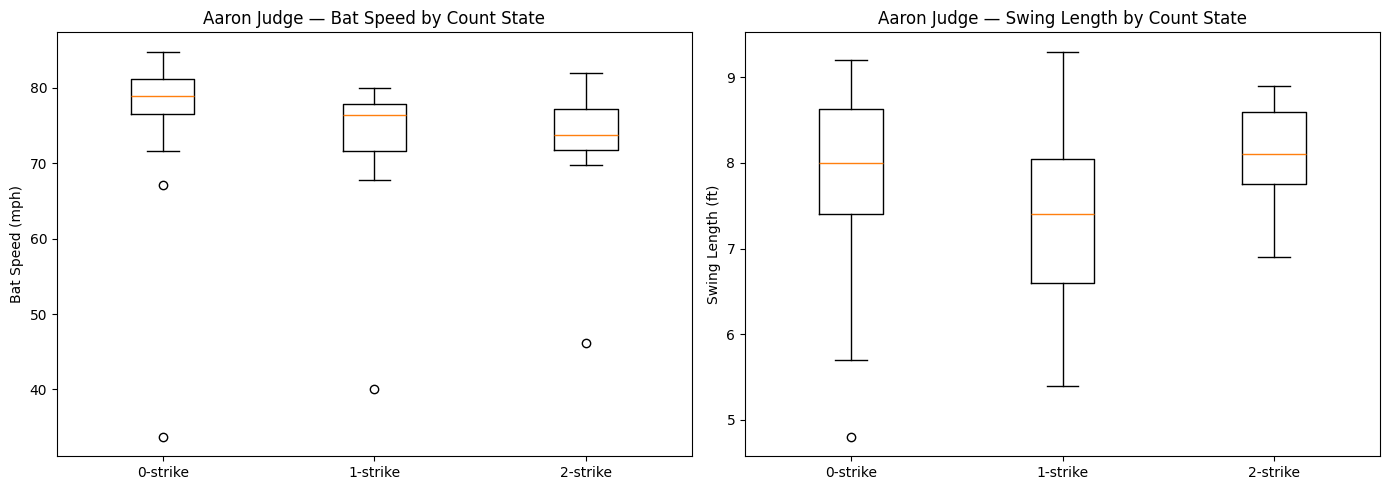

In [6]:
PLAYER_ID = 592450
PLAYER_NAME = 'Aaron Judge'

hitter = swings[swings['batter'] == PLAYER_ID]
print(f"Swings for {PLAYER_NAME}: {len(hitter)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['0-strike', '1-strike', '2-strike']
data_bs = [hitter[hitter['count_state'] == cs]['bat_speed'].dropna() for cs in order]
axes[0].boxplot(data_bs, labels=order)
axes[0].set_title(f'{PLAYER_NAME} — Bat Speed by Count State')
axes[0].set_ylabel('Bat Speed (mph)')

data_sl = [hitter[hitter['count_state'] == cs]['swing_length'].dropna() for cs in order]
axes[1].boxplot(data_sl, labels=order)
axes[1].set_title(f'{PLAYER_NAME} — Swing Length by Count State')
axes[1].set_ylabel('Swing Length (ft)')

plt.tight_layout()
plt.savefig('first_look.png', dpi=120, bbox_inches='tight')
plt.show()